# Practica de NLP con DF de videojuegos para clasificar las reviews entre positivas y negativas

# 1 Descarga y exploracion

Cabe recalcar que hay que descargar el Dataframe desde https://drive.google.com/file/d/17AD9Hhw4kEoe3ORcJKGf9MfJIGHleBav/view?usp=sharing y descomprimirlo y copiar la carpeta descomprimida en data

In [ ]:
import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import nltk
import re
from collections import Counter
from nltk.corpus import stopwords
import numpy as np
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


df = pd.read_json('..\\data\\reviews_Video_Games_5.json\\Video_Games_5.json', lines=True)
print(df.head())

       reviewerID        asin                        reviewerName  helpful  \
0  A2HD75EMZR8QLN  0700099867                                 123  [8, 12]   
1  A3UR8NLLY1ZHCX  0700099867  Alejandro Henao "Electronic Junky"   [0, 0]   
2  A1INA0F5CWW3J4  0700099867          Amazon Shopper "Mr.Repsol"   [0, 0]   
3  A1DLMTOTHQ4AST  0700099867                            ampgreen  [7, 10]   
4  A361M14PU2GUEG  0700099867        Angry Ryan "Ryan A. Forrest"   [2, 2]   

                                          reviewText  overall  \
0  Installing the game was a struggle (because of...        1   
1  If you like rally cars get this game you will ...        4   
2  1st shipment received a book instead of the ga...        1   
3  I got this version instead of the PS3 version,...        3   
4  I had Dirt 2 on Xbox 360 and it was an okay ga...        4   

                                           summary  unixReviewTime  \
0         Pay to unlock content? I don't think so.      1341792000   


Visualizamos las reviews por numero de estrellas y creamos la variable objetivo de sentimiento positivo y negativo en base a las estrellas

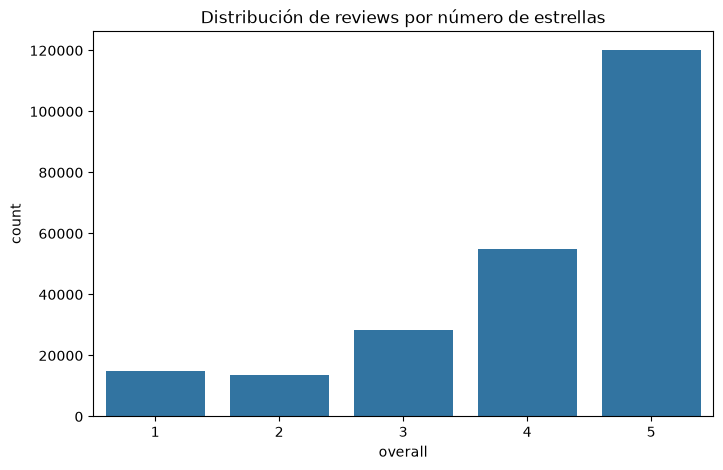

Conteo de clases:
 sentiment
1    174989
0     28516
Name: count, dtype: int64


In [ ]:
# Distribución de reviews por número de estrellas
plt.figure(figsize=(8,5))
sns.countplot(x='overall', data=df)
plt.title('Distribución de reviews por número de estrellas')
plt.show()

# Crear variable de sentimiento
df = df[df['overall'] != 3]
df['sentiment'] = df['overall'].apply(lambda x: 1 if x > 3 else 0)

# Nº de reviews positivas y negativas
print("Conteo de clases:\n", df['sentiment'].value_counts())

Buscamos los bigramas mas frecuentes, la cardinalidad del vocabulario y las nubes de palabras mas repetidas

Cardinalidad del vocabulario: 194050


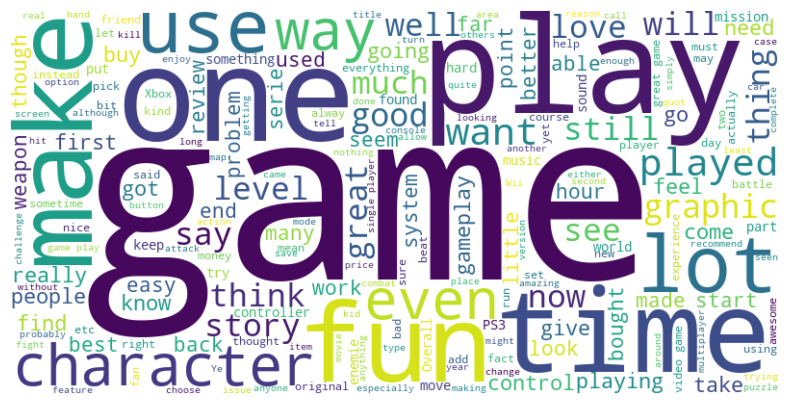

Top 10 Bigramas: ['and the' 'if you' 'in the' 'of the' 'on the' 'the game' 'this game'
 'this is' 'to the' 'you can']


In [ ]:


textos = df['reviewText'].dropna().values

# Cardinalidad del vocabulario
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(textos)
vocabulario = vectorizer.get_feature_names_out()
print(f"Cardinalidad del vocabulario: {len(vocabulario)}")

# Nube de palabras
texto_unido = " ".join(textos)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_unido)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# N-grams más frecuentes en bigramas
vectorizer_ngram = CountVectorizer(ngram_range=(2, 2), max_features=10)
X_ngram = vectorizer_ngram.fit_transform(textos)
print("Top 10 Bigramas:", vectorizer_ngram.get_feature_names_out())

Modifico temporalmente el comportamiento de SSL para que no verifique los certificados HTTPS al descargar los recursos de NLTK ya que me salio error al no hacerlo

In [ ]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Añadimos unas cuantas palabras objetivo para buscar las 10 mas proximas y las graficamos

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


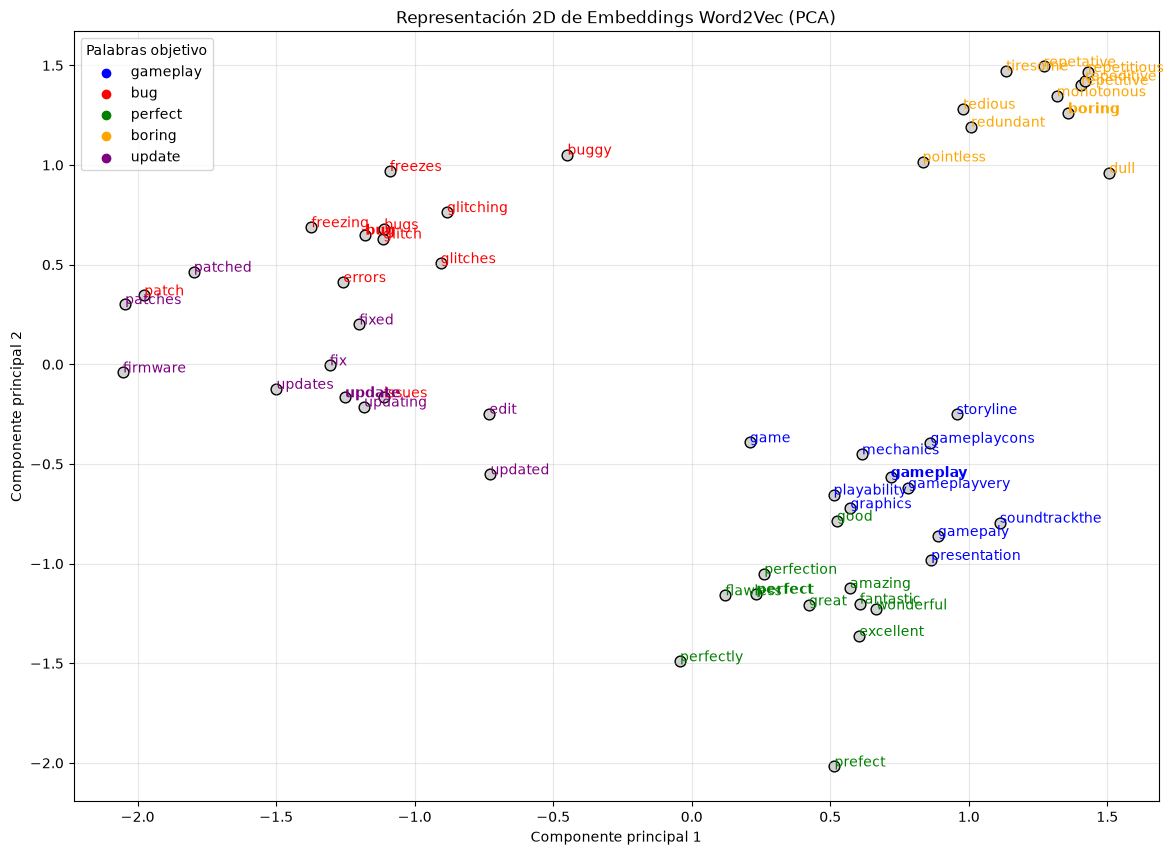

In [ ]:
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

def limpiar_texto(texto):
    texto = texto.lower()                              
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)         
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return palabras

# Crear lista de oraciones tokenizadas
oraciones = [limpiar_texto(texto) for texto in df['reviewText'].dropna()]

# Entrenar Word2Vec
modelo_w2v = Word2Vec(
    sentences=oraciones,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,          
    epochs=20
)

# Palabras objetivo
palabras_objetivo = ['gameplay', 'bug', 'perfect', 'boring', 'update']

colores = {
    'gameplay': 'blue',
    'bug': 'red',
    'perfect': 'green',
    'boring': 'orange',
    'update': 'purple'
}

palabras_a_graficar = []
grupo_palabras = {}

# Obtener palabras similares
for palabra in palabras_objetivo:

    if palabra not in modelo_w2v.wv:
        print(f'"{palabra}" no está en el vocabulario.')
        continue

    similares = modelo_w2v.wv.most_similar(palabra, topn=10)

    grupo_palabras[palabra] = [palabra]
    palabras_a_graficar.append(palabra)

    for sim, _ in similares:
        grupo_palabras[palabra].append(sim)
        palabras_a_graficar.append(sim)

# Eliminar duplicados conservando el orden
palabras_a_graficar = list(dict.fromkeys(palabras_a_graficar))

# Obtener vectores
vectores = np.array([modelo_w2v.wv[p] for p in palabras_a_graficar])

# Reducir dimensiones con PCA
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores)

plt.figure(figsize=(14,10))

plt.scatter(
    vectores_2d[:,0],
    vectores_2d[:,1],
    color='lightgray',
    edgecolors='black',
    s=60
)

for i, palabra in enumerate(palabras_a_graficar):

    color = 'black'

    for objetivo, grupo in grupo_palabras.items():
        if palabra in grupo:
            color = colores[objetivo]
            break

    plt.annotate(
        palabra,
        (vectores_2d[i,0], vectores_2d[i,1]),
        fontsize=10,
        color=color,
        weight='bold' if palabra in palabras_objetivo else 'normal'
    )

for objetivo, color in colores.items():
    plt.scatter([], [], color=color, label=objetivo)

plt.legend(title='Palabras objetivo')

plt.title('Representación 2D de Embeddings Word2Vec (PCA)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(alpha=0.3)

plt.show()

añadimos una longitud de cada review en cada palabra y podemos observar que las reseñas negativas tienden a tener un minimo de palabras mayor que las positivas

count    203505.000000
mean        198.411921
std         271.860080
min           0.000000
25%          43.000000
50%         102.000000
75%         239.000000
max        5872.000000
Name: review_length, dtype: float64


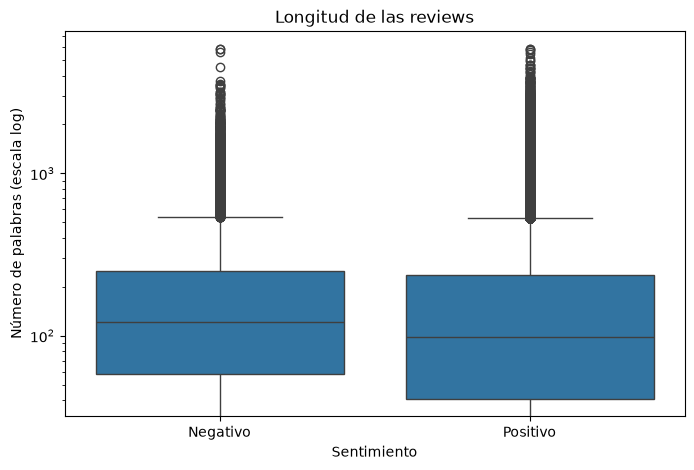

In [57]:
# Longitud de cada review (en número de palabras)
df['review_length'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

print(df['review_length'].describe())

plt.figure(figsize=(8,5))

sns.boxplot(
    x='sentiment',
    y='review_length',
    data=df
)

plt.yscale("log")

plt.xticks([0,1], ['Negativo','Positivo'])
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras (escala log)")
plt.title("Longitud de las reviews")

plt.show()

# 2. Preprocesamiento

Añadimos un preprocesamiento de nuestros datos eliminando minusculas, urls, numeros, signos de puntuacion, tokenizamos, stopwords y lematizamos

In [ ]:
nltk.download("wordnet")

# Stopwords y lematizador
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def convertir_minusculas(texto):
    return texto.lower()


def eliminar_urls(texto):
    return re.sub(r'http\S+|www\S+', '', texto)


def eliminar_numeros(texto):
    return re.sub(r'\d+', '', texto)


def eliminar_puntuacion(texto):
    return texto.translate(str.maketrans('', '', string.punctuation))


def tokenizar(texto):
    return texto.split()


def eliminar_stopwords(tokens):
    return [palabra for palabra in tokens if palabra not in stop_words]


def lematizar(tokens):
    return [lemmatizer.lemmatize(palabra) for palabra in tokens]


def preprocesar_review(texto):

    texto = convertir_minusculas(texto)

    texto = eliminar_urls(texto)

    texto = eliminar_numeros(texto)

    texto = eliminar_puntuacion(texto)

    tokens = tokenizar(texto)

    tokens = eliminar_stopwords(tokens)

    tokens = lematizar(tokens)

    return " ".join(tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Samuel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Limpiamos el DF

In [59]:
df["reviewText_clean"] = df["reviewText"].fillna("").apply(preprocesar_review)

print(df[["reviewText", "reviewText_clean"]].head())

                                          reviewText  \
0  Installing the game was a struggle (because of...   
1  If you like rally cars get this game you will ...   
2  1st shipment received a book instead of the ga...   
4  I had Dirt 2 on Xbox 360 and it was an okay ga...   
5  Overall this is a well done racing game, with ...   

                                    reviewText_clean  
0  installing game struggle game window live bugs...  
1  like rally car get game funit oriented europea...  
2  st shipment received book instead gamend shipm...  
4  dirt xbox okay game started playing game lapto...  
5  overall well done racing game good graphic tim...  


# 3. Entrenamos los modelos

Separamos los datos de la variable objetivo

In [60]:
X = df["reviewText_clean"]
y = df["sentiment"]

Separamos en train y test

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=26,
    stratify=y
)

Generamos un pipeline para buscar nuestros mejores parametros en regresión logistica con un cv de 5 y luego hacemos lo mismo para LinearSVC

In [77]:
pipeline_lr = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

param_grid_lr = {

    "vectorizer__max_features": [10000],

    "vectorizer__min_df":[5],

    "vectorizer__max_df":[0.8],

    "vectorizer__ngram_range":[
        (1,1),
        (1,2)
    ],

    "classifier__C":[
        0.1,
        1,
        10
    ]

}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [78]:
pipeline_svm = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_svm = {

    "vectorizer__max_features": [10000],

    "vectorizer__min_df":[5],

    "vectorizer__max_df":[0.8],

    "vectorizer__ngram_range":[
        (1,1),
        (1,2)
    ],

    "classifier__C":[
        0.1,
        1,
        10
    ]

}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

Entrenamos ambos modelos

In [ ]:
print("Entrenando Regresión Logística...")
grid_lr.fit(X_train, y_train)

print("Entrenando Linear SVM...")
grid_svm.fit(X_train, y_train)

Entrenando Regresión Logística...
Entrenando Linear SVM...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'vectorizer__max_df': [0.8], 'vectorizer__max_features': [10000], 'vectorizer__min_df': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,

Mostramos los mejores parametros para cada modelo y cual nos da un mejor F1

In [88]:
print("REGRESIÓN LOGÍSTICA")

print("Mejor F1:", round(grid_lr.best_score_,4))
print("Mejores parámetros:")
print(grid_lr.best_params_)

print("\nLINEAR SVM")

print("Mejor F1:", round(grid_svm.best_score_,4))
print("Mejores parámetros:")
print(grid_svm.best_params_)

REGRESIÓN LOGÍSTICA
Mejor F1: 0.9413
Mejores parámetros:
{'classifier__C': 0.1, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 10000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}

LINEAR SVM
Mejor F1: 0.9373
Mejores parámetros:
{'classifier__C': 0.1, 'vectorizer__max_df': 0.8, 'vectorizer__max_features': 10000, 'vectorizer__min_df': 5, 'vectorizer__ngram_range': (1, 2)}


Comparamos y decidimos quedarnos con el modelo de Regresión Logistica ya que nos da un mejor F1 y encima es mas rápido y eficiente

In [82]:
comparacion = pd.DataFrame({

    "Modelo":[
        "Regresión Logística",
        "Linear SVM"
    ],

    "F1 Cross Validation":[
        grid_lr.best_score_,
        grid_svm.best_score_
    ]

})

print("\n")
print(comparacion)
if grid_lr.best_score_ >= grid_svm.best_score_:

    mejor_modelo = grid_lr.best_estimator_
    nombre = "Regresión Logística"

else:

    mejor_modelo = grid_svm.best_estimator_
    nombre = "Linear SVM"

print(f"\nModelo seleccionado: {nombre}")



                Modelo  F1 Cross Validation
0  Regresión Logística             0.941319
1           Linear SVM             0.937304

Modelo seleccionado: Regresión Logística


Realizamos la prediccion de nuestro modelo con test y observamos las métricas

In [85]:
pred = mejor_modelo.predict(X_test)

print("RESULTADOS EN TEST")

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision:", round(precision_score(y_test,pred),4))
print("Recall   :", round(recall_score(y_test,pred),4))
print("F1-score :", round(f1_score(y_test,pred),4))

print("\nClassification Report\n")

print(classification_report(y_test,pred))

RESULTADOS EN TEST
Accuracy : 0.9044
Precision: 0.9739
Recall   : 0.9133
F1-score : 0.9426

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.85      0.71      5703
           1       0.97      0.91      0.94     34998

    accuracy                           0.90     40701
   macro avg       0.79      0.88      0.83     40701
weighted avg       0.92      0.90      0.91     40701



Realizamos una matriz de confusión para ver cuantos falsos positivos y falsos negativos tenemos con nuestro modelo 

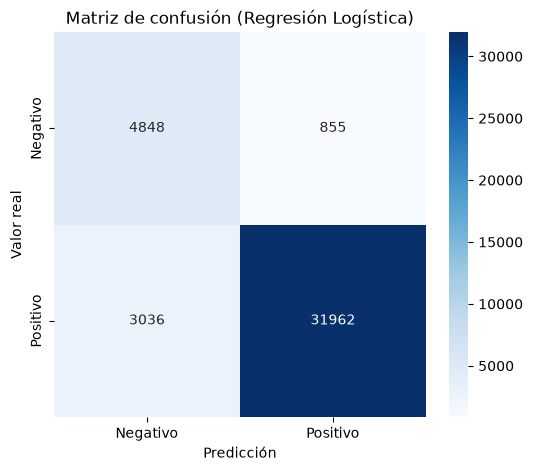

In [84]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativo","Positivo"],
    yticklabels=["Negativo","Positivo"]
)

plt.title(f"Matriz de confusión ({nombre})")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()